# Centerline flow & PI vs LOC analysis

Simple analysis of flow and pulsatility index (PI) along each vessel centerline from the centerline test pipeline, and comparison to the final measured **LOC** (location of interest) per vessel.

- **Data**: `centerline_test/flow_PI_per_centerline_centerline_test.xlsx` (per participant) and `centerline_test/SummaryParamTool.xls` (LOC flow/PI per vessel).
- **Goal**: Compare flow/PI at the chosen LOC to the distribution along the full centerline (mean, spread, difference).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Configuration

Set `QVT_PLUS_BASE` to the root directory containing one folder per participant (e.g. `RESULTS/QVTPlus`). Each participant folder must contain `centerline_test/` with the centerline and summary files.

In [11]:
# Base path: one subfolder per participant, each with centerline_test/
QVT_PLUS_BASE = Path("/data_local/LabVF/PESA-Brain/RESULTS/Auxiliary/QVTPlus_ReLOCs/")
CENTERLINE_XLSX = "flow_PI_per_centerline_centerline_test.xlsx"
CENTERLINE_CSV = "flow_PI_per_centerline_centerline_test.csv"
SUMMARY_XLS = "SummaryParamTool.xls"
CENTERLINE_DIR = "centerline_test"

# Mapping from SummaryParamTool 'Vessel Label' to centerline vessel_name (key)
LABEL_TO_KEY = {
    "Left ICA": "LICA", "Right ICA": "RICA", "Basilar": "BASI",
    "Left MCA": "LMCA", "Right MCA": "RMCA", "Left PCA": "LPCA", "Right PCA": "RPCA",
    "Left ACA": "LACA", "Right ACA": "RACA",
    # "Right Communicating": "RCOMM", "Left Communicating": "LCOMM",
    "Straight Sinus": "STRV", "Sagital Sinus": "SSSV",
    "Left Transverse": "LTSV", "Right Transverse": "RTSV",
}

if not QVT_PLUS_BASE.exists():
    raise FileNotFoundError(f"QVT Plus base not found: {QVT_PLUS_BASE}")

## Discover participants and load data

In [12]:
def find_centerline_files(base: Path):
    """Return list of (participant_id, centerline_path, summary_path)."""
    out = []
    for pdir in sorted(base.iterdir()):
        if not pdir.is_dir() or pdir.name.startswith("."):
            continue
        cdir = pdir / CENTERLINE_DIR
        xlsx = cdir / CENTERLINE_XLSX
        csv = cdir / CENTERLINE_CSV
        summary = cdir / SUMMARY_XLS
        path_cl = xlsx if xlsx.exists() else (csv if csv.exists() else None)
        if path_cl is not None and summary.exists():
            out.append((pdir.name, path_cl, summary))
    return out

participants = find_centerline_files(QVT_PLUS_BASE)
print(f"Found {len(participants)} participants with centerline_test data.")
if participants:
    for pid, pcl, psum in participants[:5]:
        print(f"  {pid}: {pcl.name}, {psum.name}")
    if len(participants) > 5:
        print(f"  ... and {len(participants) - 5} more.")

Found 11 participants with centerline_test data.
  PESA10758400: flow_PI_per_centerline_centerline_test.xlsx, SummaryParamTool.xls
  PESA11937025: flow_PI_per_centerline_centerline_test.xlsx, SummaryParamTool.xls
  PESA12517444: flow_PI_per_centerline_centerline_test.xlsx, SummaryParamTool.xls
  PESA15792676: flow_PI_per_centerline_centerline_test.xlsx, SummaryParamTool.xls
  PESA2196324: flow_PI_per_centerline_centerline_test.xlsx, SummaryParamTool.xls
  ... and 6 more.


In [13]:
def load_summary_loc(summary_path: Path) -> pd.DataFrame:
    """Load Summary_Centerline sheet; columns: Vessel Label, Mean Flow ml/s, Pulsatility Index."""
    suf = summary_path.suffix.lower()
    try:
        if suf == ".xls":
            df = pd.read_excel(summary_path, sheet_name="Summary_Centerline", engine="xlrd")
        else:
            df = pd.read_excel(summary_path, sheet_name="Summary_Centerline", engine="openpyxl")
    except Exception:
        try:
            df = pd.read_excel(summary_path, sheet_name=0)
        except Exception as e:
            raise FileNotFoundError(f"Cannot read {summary_path}: {e}") from e
    # Normalize column names
    cols = {c.strip(): c for c in df.columns}
    rename = {}
    if "Vessel Label" in cols:
        rename[cols["Vessel Label"]] = "Vessel Label"
    if "Mean Flow ml/s" in cols:
        rename[cols["Mean Flow ml/s"]] = "flow_LOC"
    if "Pulsatility Index" in cols:
        rename[cols["Pulsatility Index"]] = "PI_LOC"
    df = df.rename(columns=rename)
    return df

def load_centerline_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    return pd.read_excel(path, engine="openpyxl")

# Load all participants
all_centerline = []
all_summary = []
for pid, pcl, psum in participants:
    try:
        cl = load_centerline_table(pcl).assign(participant_id=pid)
        sm = load_summary_loc(psum).assign(participant_id=pid)
        all_centerline.append(cl)
        all_summary.append(sm)
    except Exception as e:
        print(f"Skip {pid}: {e}")

df_centerline = pd.concat(all_centerline, ignore_index=True) if all_centerline else pd.DataFrame()
df_summary = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()

if not df_centerline.empty:
    print("Centerline table columns:", list(df_centerline.columns))
    print("Summary table columns:", [c for c in df_summary.columns if c in ["Vessel Label", "flow_LOC", "PI_LOC"]])
    print(f"Centerline rows: {len(df_centerline)}, participants: {df_centerline['participant_id'].nunique()}")

Centerline table columns: ['vessel_name', 'segment_id', 'centerline_point_index', 'point_index', 'flow_ml_s', 'PI', 'area_val', 'circularity', 'participant_id']
Summary table columns: ['Vessel Label', 'flow_LOC', 'PI_LOC']
Centerline rows: 6137, participants: 11


## Map Summary vessel labels to centerline keys and merge LOC values

In [14]:
if not df_summary.empty and "Vessel Label" in df_summary.columns:
    df_summary["vessel_name"] = df_summary["Vessel Label"].map(LABEL_TO_KEY)
    df_summary = df_summary.dropna(subset=["vessel_name"])
    # One row per participant per vessel (LOC flow and PI)
    loc_cols = ["participant_id", "vessel_name", "flow_LOC", "PI_LOC"]
    df_loc = df_summary[[c for c in loc_cols if c in df_summary.columns]].copy()
    df_loc["flow_LOC"] = pd.to_numeric(df_loc["flow_LOC"], errors="coerce")
    df_loc["PI_LOC"] = pd.to_numeric(df_loc["PI_LOC"], errors="coerce")
    print(df_loc.head(10))

   participant_id vessel_name  flow_LOC    PI_LOC
0    PESA10758400        LICA  6.578361  0.836879
1    PESA10758400        RICA  6.918622  0.828595
2    PESA10758400        BASI  4.102279  0.784452
3    PESA10758400        LMCA  2.866245  0.834843
4    PESA10758400        RMCA  3.361837  0.743924
5    PESA10758400        LPCA  1.317806  0.883069
6    PESA10758400        RPCA  1.327290  0.805071
7    PESA10758400        LACA  1.012839  0.753212
8    PESA10758400        RACA  2.423142  0.658042
11   PESA10758400        STRV  1.004679  0.632970


## Per-vessel centerline stats (mean flow, mean PI) and comparison to LOC

In [15]:
if df_centerline.empty:
    raise ValueError("No centerline data loaded.")

# Aggregate centerline: mean flow and mean PI per participant per vessel
flow_col = "flow_ml_s" if "flow_ml_s" in df_centerline.columns else "flow_ml_s"
pi_col = "PI" if "PI" in df_centerline.columns else "PI"
for c in [flow_col, pi_col]:
    if c not in df_centerline.columns:
        print(f"Column missing: {c}. Available: {list(df_centerline.columns)}")

cl_agg = (
    df_centerline.groupby(["participant_id", "vessel_name"], dropna=False)
    .agg(
        flow_mean=("flow_ml_s", "mean"),
        flow_std=("flow_ml_s", "std"),
        flow_median=("flow_ml_s", "median"),
        PI_mean=(pi_col, "mean"),
        PI_std=(pi_col, "std"),
        PI_median=(pi_col, "median"),
        n_points=("centerline_point_index", "count"),
    )
    .reset_index()
)

# Merge with LOC values
compare = cl_agg.merge(df_loc, on=["participant_id", "vessel_name"], how="inner")
compare["flow_diff"] = compare["flow_LOC"] - compare["flow_mean"]
compare["flow_diff_pct"] = 100 * (compare["flow_LOC"] - compare["flow_mean"]) / compare["flow_mean"].replace(0, np.nan)
compare["PI_diff"] = compare["PI_LOC"] - compare["PI_mean"]
compare["PI_diff_pct"] = 100 * (compare["PI_LOC"] - compare["PI_mean"]) / compare["PI_mean"].replace(0, np.nan)

print("Comparison (LOC vs centerline mean) - first rows:")
display(compare.head(12))

Comparison (LOC vs centerline mean) - first rows:


,participant_id,vessel_name,flow_mean,flow_std,flow_median,PI_mean,PI_std,PI_median,n_points,flow_LOC,PI_LOC,flow_diff,flow_diff_pct,PI_diff,PI_diff_pct
0,PESA10758400,BASI,2.837857,0.628245,2.667023,0.847344,0.101841,0.826944,32,4.102279,0.784452,1.264421,44.555498,-0.062892,-7.422234
1,PESA10758400,LACA,0.911012,0.173541,0.919414,0.833607,0.125772,0.828111,49,1.012839,0.753212,0.101827,11.177372,-0.080394,-9.644139
2,PESA10758400,LICA,5.534962,0.802724,5.454862,0.792655,0.042149,0.805742,9,6.578361,0.836879,1.043399,18.851063,0.044224,5.579260
3,PESA10758400,LMCA,3.081285,0.319273,2.970946,0.834311,0.051671,0.838864,27,2.866245,0.834843,-0.215040,-6.978892,0.000533,0.063826
4,PESA10758400,LPCA,1.305414,0.141283,1.329434,1.004776,0.111996,0.999692,16,1.317806,0.883069,0.012392,0.949303,-0.121706,-12.112791
5,PESA10758400,LTSV,5.419845,1.415043,6.157768,0.268988,0.034172,0.277444,164,5.521790,0.213383,0.101945,1.880965,-0.055605,-20.671833
6,PESA10758400,RACA,2.367615,0.187730,2.351185,0.715799,0.058850,0.719644,16,2.423142,0.658042,0.055527,2.345259,-0.057758,-8.068965
7,PESA10758400,RICA,6.136904,0.602252,5.995963,0.836395,0.069959,0.841585,56,6.918622,0.828595,0.781718,12.737985,-0.007800,-0.932551
8,PESA10758400,RMCA,3.622562,0.359573,3.531505,0.831086,0.072331,0.829193,21,3.361837,0.743924,-0.260726,-7.197273,-0.087162,-10.487732
9,PESA10758400,RPCA,1.319769,0.110921,1.331307,0.865790,0.101202,0.849547,28,1.327290,0.805071,0.007521,0.569875,-0.060719,-7.013093


## Flow: LOC vs centerline mean (scatter)

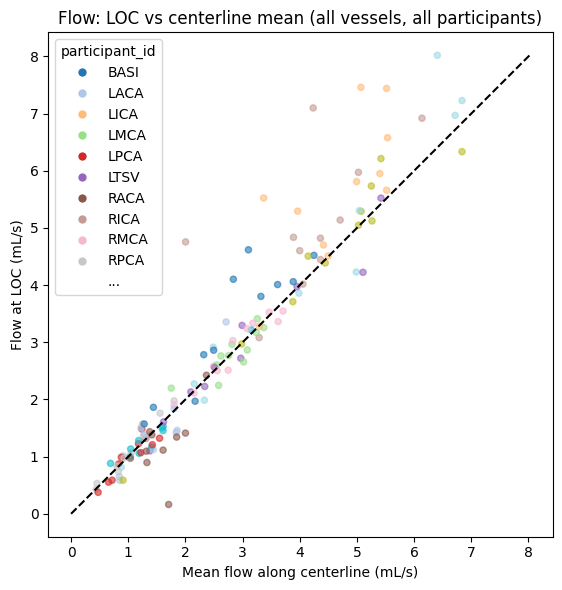

In [16]:
# Color hue each scatter by participant_id
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Get unique participant_ids and assign each a color from a colormap
unique_ids = compare["vessel_name"].unique()
cmap = plt.get_cmap("tab20", len(unique_ids))
id_color_map = {pid: cmap(i) for i, pid in enumerate(unique_ids)}
colors = compare["vessel_name"].map(id_color_map)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
scatter = ax.scatter(compare["flow_mean"], compare["flow_LOC"], alpha=0.6, s=20, c=colors)

mx = max(compare["flow_mean"].max(), compare["flow_LOC"].max())
ax.plot([0, mx], [0, mx], "k--", label="y=x")
ax.set_xlabel("Mean flow along centerline (mL/s)")
ax.set_ylabel("Flow at LOC (mL/s)")
ax.set_title("Flow: LOC vs centerline mean (all vessels, all participants)")
ax.set_aspect("equal")

# Legend by participant_id (show first 10 or all if <=10)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=id_color_map[pid], label=pid, markersize=7)
    for pid in unique_ids[:10]
]
if len(unique_ids) > 10:
    legend_elements.append(Line2D([0], [0], marker='', color='w', label="..."))

ax.legend(handles=legend_elements, title="participant_id")

plt.tight_layout()
plt.show()

## PI: LOC vs centerline mean (scatter)

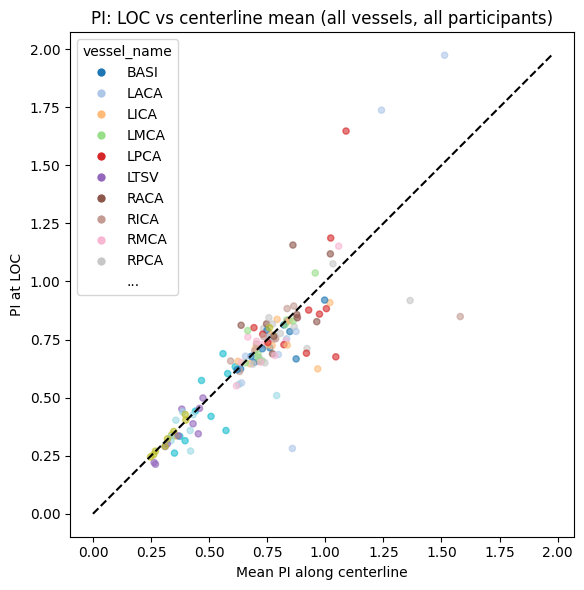

In [18]:
# Color hue each scatter by vessel_name
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Get unique vessel_names and assign each a color from a colormap
unique_vessels = compare["vessel_name"].unique()
cmap = plt.get_cmap("tab20", len(unique_vessels))
vessel_color_map = {vessel: cmap(i) for i, vessel in enumerate(unique_vessels)}
colors = compare["vessel_name"].map(vessel_color_map)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
scatter = ax.scatter(compare["PI_mean"], compare["PI_LOC"], alpha=0.6, s=20, c=colors)

mx = max(compare["PI_mean"].max(), compare["PI_LOC"].max())
ax.plot([0, mx], [0, mx], "k--", label="y=x")
ax.set_xlabel("Mean PI along centerline")
ax.set_ylabel("PI at LOC")
ax.set_title("PI: LOC vs centerline mean (all vessels, all participants)")
ax.set_aspect("equal")

# Legend by vessel_name (show first 10 or all if <=10)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=vessel_color_map[vessel], label=vessel, markersize=7)
    for vessel in unique_vessels[:10]
]
if len(unique_vessels) > 10:
    legend_elements.append(Line2D([0], [0], marker='', color='w', label="..."))

ax.legend(handles=legend_elements, title="vessel_name")

plt.tight_layout()
plt.show()

## Flow difference (LOC − centerline mean) by vessel

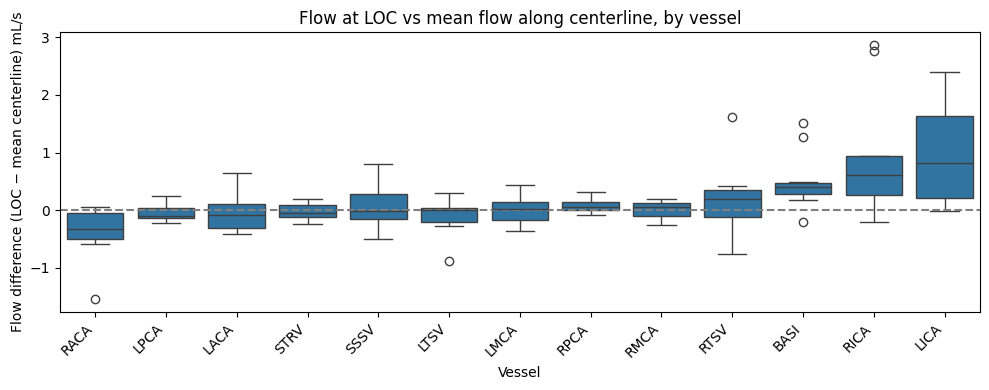

In [19]:
if compare["vessel_name"].nunique() > 1:
    order = compare.groupby("vessel_name")["flow_diff"].median().sort_values().index
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=compare, x="vessel_name", y="flow_diff", order=order, ax=ax)
    ax.axhline(0, color="gray", linestyle="--")
    ax.set_xlabel("Vessel")
    ax.set_ylabel("Flow difference (LOC − mean centerline) mL/s")
    ax.set_title("Flow at LOC vs mean flow along centerline, by vessel")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Single vessel; skipping boxplot.")

## PI difference (LOC − centerline mean) by vessel

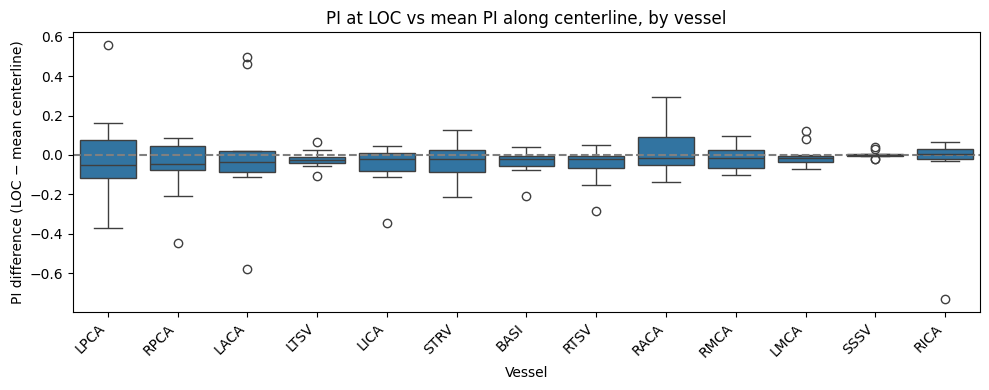

In [20]:
if compare["vessel_name"].nunique() > 1:
    order = compare.groupby("vessel_name")["PI_diff"].median().sort_values().index
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=compare, x="vessel_name", y="PI_diff", order=order, ax=ax)
    ax.axhline(0, color="gray", linestyle="--")
    ax.set_xlabel("Vessel")
    ax.set_ylabel("PI difference (LOC − mean centerline)")
    ax.set_title("PI at LOC vs mean PI along centerline, by vessel")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Single vessel; skipping boxplot.")

## Flow along centerline (example: one participant, selected vessels)

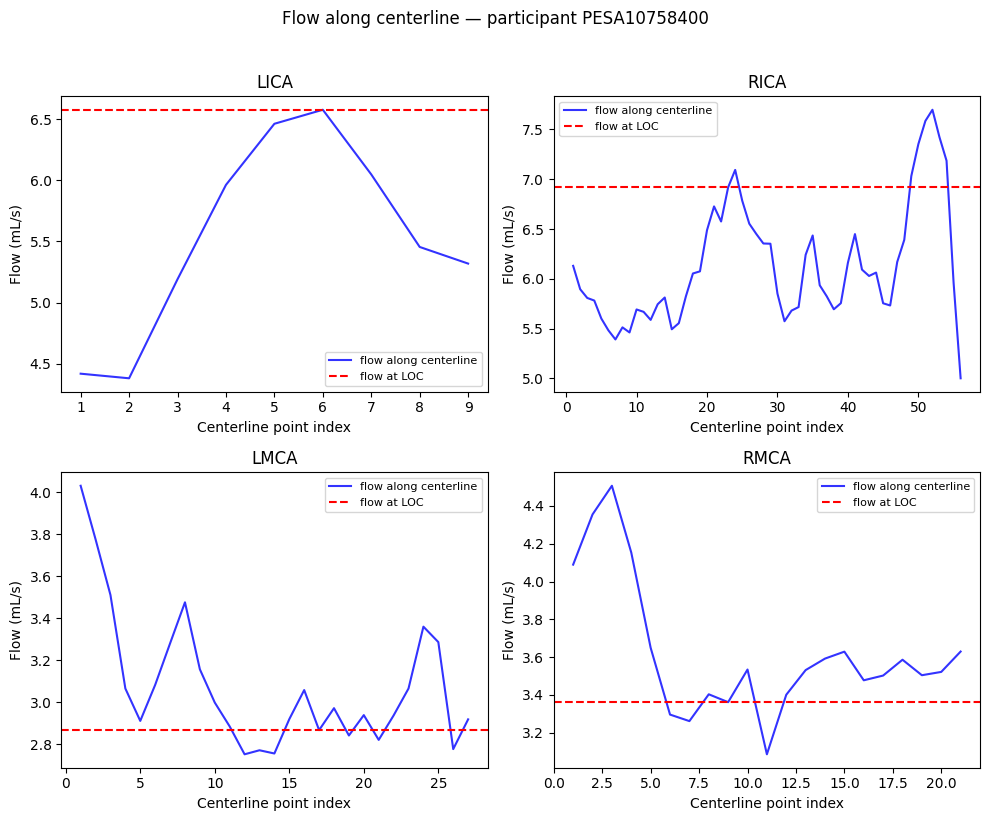

In [ ]:
ex_pid = df_centerline["participant_id"].iloc[0]
vessels_show = ["LICA", "RICA", "LMCA", "RMCA"]
sub = df_centerline[(df_centerline["participant_id"] == ex_pid) & (df_centerline["vessel_name"].isin(vessels_show))]
loc_sub = df_loc[(df_loc["participant_id"] == ex_pid) & (df_loc["vessel_name"].isin(vessels_show))]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, v in enumerate(vessels_show):
    ax = axes[i]
    vcl = sub[sub["vessel_name"] == v].sort_values("centerline_point_index")
    vloc = loc_sub[loc_sub["vessel_name"] == v]
    if vcl.empty:
        ax.set_title(f"{v} (no data)")
        continue
    ax.plot(vcl["centerline_point_index"], vcl["flow_ml_s"], "b-", alpha=0.8, label="flow along centerline")
    flow_loc = vloc["flow_LOC"].values
    if len(flow_loc) and np.isfinite(flow_loc[0]):
        ax.axhline(flow_loc[0], color="red", linestyle="--", label="flow at LOC")
    ax.set_xlabel("Centerline point index")
    ax.set_ylabel("Flow (mL/s)")
    ax.set_title(v)
    ax.legend(loc="best", fontsize=8)
plt.suptitle(f"Flow along centerline — participant {ex_pid}", y=1.02)
plt.tight_layout()
plt.show()